# 09 — PCA Dimension Ablation (archived null)

**Status: archived null result.** The `analyze_pca_ablation_runs/_merge` stages
have been removed from the DVC graph. Outputs remain at
`results/*/*/*_pca_ablation_results.json`.

Objective:
- Measure how geometry performance changes with PCA truncation size
  ({32, 128, 512, max}) across 4 conditions x 3 layers.
- Test specifically whether `max` (no truncation) beats the default `128`.

**Bottom line: `pca_dim` is not a tuned knob, and that is the useful finding.**
Combined-AUC spread across dimensions is roughly ±0.03 and non-monotone in every
cell; `128` is best or within 0.01 of best in 9 of 12 cells; `max` wins in only
2 cells (both DeepSeek GSM8K) and is the *worst* option on both MATH-500
conditions. There is no consistent direction to tune toward.

**Why this null is worth keeping:** it closes the "PCA dim fixed at 128, never
swept" limitation in `FINDINGS.md` with evidence, instead of leaving it as an
open caveat a reviewer can pull on.

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)


In [2]:
MAX_PCA_DIM_ALIASES = {"max", "all"}


def normalize_dim_label(raw_dim: object) -> str:
    token = str(raw_dim).strip().lower()
    if token in MAX_PCA_DIM_ALIASES:
        return "max"
    dim = int(token)
    if dim <= 0:
        raise ValueError(f"PCA dim must be positive or max/all, got {raw_dim!r}")
    return str(dim)


def dim_sort_key(label: str) -> tuple[int, int]:
    return (1, 0) if label == "max" else (0, int(label))


def format_table(rows: list[list[object]], headers: list[str]) -> str:
    if not rows:
        return "(no rows)"
    table_rows = [headers, *[[str(item) for item in row] for row in rows]]
    widths = [max(len(row[i]) for row in table_rows) for i in range(len(headers))]

    def fmt_row(row: list[str]) -> str:
        return " | ".join(cell.ljust(widths[i]) for i, cell in enumerate(row))

    separator = "-+-".join("-" * width for width in widths)
    lines = [fmt_row(table_rows[0]), separator]
    lines.extend(fmt_row(row) for row in table_rows[1:])
    return "\n".join(lines)


results_dir = vu.results_root()
pca_paths = sorted(results_dir.glob("*/*/*_pca_ablation_results.json"))
if not pca_paths:
    raise FileNotFoundError(
        "No PCA ablation outputs found. Run DVC stages: analyze_pca_ablation_runs and analyze_pca_ablation_merge."
    )

ablation_rows: list[dict[str, object]] = []
layer_rows: list[dict[str, object]] = []

for path in pca_paths:
    payload = vu.load_json(path)
    model = str(payload.get("model") or path.parent.parent.name)
    dataset = str(payload.get("dataset") or path.parent.name)

    for layer_key, layer_payload in payload.get("layers", {}).items():
        layer = int(layer_key)
        best_dim_raw = layer_payload.get("best_dim_by_combined_auc")
        best_dim = normalize_dim_label(best_dim_raw) if best_dim_raw is not None else None
        layer_rows.append(
            {
                "model": model,
                "dataset": dataset,
                "layer": layer,
                "best_dim": best_dim,
                "monotone": bool(layer_payload.get("combined_auc_monotone_non_decreasing", False)),
            }
        )

        for dim_key, metrics in layer_payload.get("dims", {}).items():
            dim = normalize_dim_label(dim_key)
            ablation_rows.append(
                {
                    "model": model,
                    "dataset": dataset,
                    "layer": layer,
                    "dim": dim,
                    "dim_sort": dim_sort_key(dim),
                    "mahal_auc": float(metrics["mahalanobis_only"]["roc_auc_mean"]),
                    "combined_auc": float(metrics["combined"]["roc_auc_mean"]),
                    "delta_raw": float(metrics.get("delta_vs_entropy", float("nan"))),
                    "delta_len": float(metrics.get("length_controlled_delta", float("nan"))),
                }
            )

conditions = sorted({(row["model"], row["dataset"]) for row in ablation_rows})
dims = sorted({row["dim"] for row in ablation_rows}, key=dim_sort_key)
layers = sorted({int(row["layer"]) for row in ablation_rows})

print(f"Loaded {len(pca_paths)} PCA ablation files")
print(f"Conditions: {len(conditions)} -> {conditions}")
print(f"Dims: {dims}")
print(f"Layers observed: {layers}")


Loaded 4 PCA ablation files
Conditions: 4 -> [('deepseek', 'gsm8k'), ('deepseek', 'math500'), ('qwen', 'gsm8k'), ('qwen', 'math500')]
Dims: ['32', '128', '512', 'max']
Layers observed: [7, 14, 21]


In [3]:
summary_rows = []
for row in sorted(layer_rows, key=lambda r: (r["model"], r["dataset"], r["layer"])):
    summary_rows.append(
        [
            row["model"],
            row["dataset"],
            f"L{row['layer']}",
            row["best_dim"] or "-",
            "yes" if row["monotone"] else "no",
        ]
    )

print("Per-layer PCA ablation summary")
print(format_table(summary_rows, ["model", "dataset", "layer", "best_dim", "monotone"]))

monotone_counts = {}
for row in layer_rows:
    key = (row["model"], row["dataset"])
    if key not in monotone_counts:
        monotone_counts[key] = {"yes": 0, "total": 0}
    monotone_counts[key]["total"] += 1
    if row["monotone"]:
        monotone_counts[key]["yes"] += 1

print()
print("Monotone layer share by condition")
for key in sorted(monotone_counts):
    yes = monotone_counts[key]["yes"]
    total = monotone_counts[key]["total"]
    print(f"{key[0]}/{key[1]}: {yes}/{total} ({yes / total:.0%})")


Per-layer PCA ablation summary
model    | dataset | layer | best_dim | monotone
---------+---------+-------+----------+---------
deepseek | gsm8k   | L7    | 128      | no      
deepseek | gsm8k   | L14   | max      | no      
deepseek | gsm8k   | L21   | max      | no      
deepseek | math500 | L7    | 128      | no      
deepseek | math500 | L14   | 32       | no      
deepseek | math500 | L21   | 32       | no      
qwen     | gsm8k   | L7    | 128      | no      
qwen     | gsm8k   | L14   | 128      | no      
qwen     | gsm8k   | L21   | 128      | no      
qwen     | math500 | L7    | 128      | no      
qwen     | math500 | L14   | 128      | no      
qwen     | math500 | L21   | 512      | no      

Monotone layer share by condition
deepseek/gsm8k: 0/3 (0%)
deepseek/math500: 0/3 (0%)
qwen/gsm8k: 0/3 (0%)
qwen/math500: 0/3 (0%)


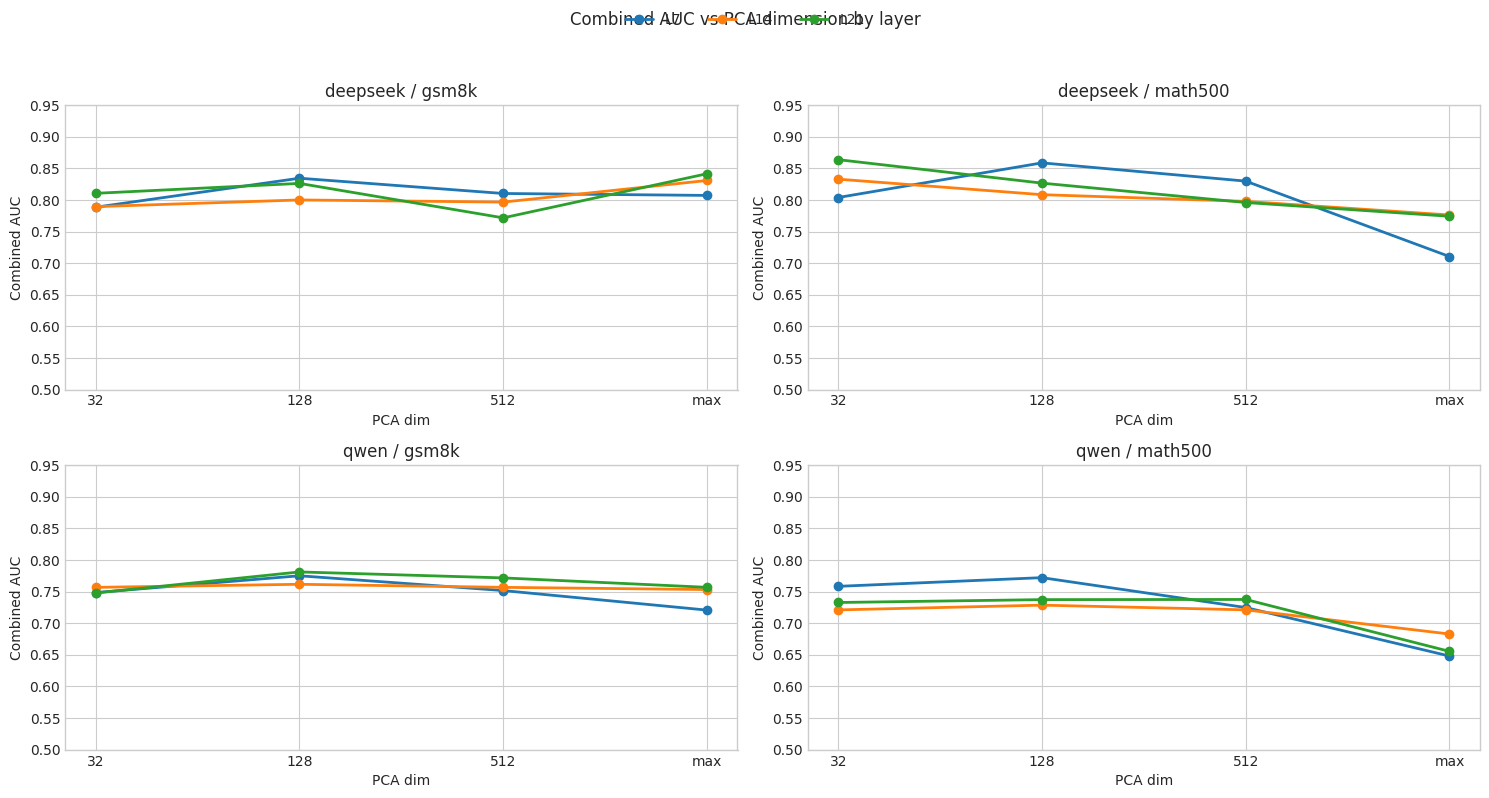

In [4]:
def rows_for(model: str, dataset: str, layer: int | None = None):
    selected = [r for r in ablation_rows if r["model"] == model and r["dataset"] == dataset]
    if layer is not None:
        selected = [r for r in selected if int(r["layer"]) == layer]
    return sorted(selected, key=lambda r: (int(r["layer"]), r["dim_sort"]))


n_cols = 2
n_rows = max(1, math.ceil(len(conditions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5 * n_cols, 4.0 * n_rows), squeeze=False)

for ax, (model, dataset) in zip(axes.flat, conditions):
    subset = rows_for(model, dataset)
    dims_local = sorted({str(r["dim"]) for r in subset}, key=dim_sort_key)
    x = np.arange(len(dims_local))
    layers_local = sorted({int(r["layer"]) for r in subset})

    for layer in layers_local:
        y = []
        for dim in dims_local:
            match = next((r for r in subset if int(r["layer"]) == layer and str(r["dim"]) == dim), None)
            y.append(np.nan if match is None else float(match["combined_auc"]))
        ax.plot(x, y, marker="o", linewidth=2, label=f"L{layer}")

    ax.set_title(f"{model} / {dataset}")
    ax.set_xticks(x, dims_local)
    ax.set_xlabel("PCA dim")
    ax.set_ylabel("Combined AUC")
    ax.set_ylim(0.5, 0.95)

for ax in axes.flat[len(conditions):]:
    ax.axis("off")

handles, labels = axes.flat[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=min(6, len(labels)), frameon=False)

fig.suptitle("Combined AUC vs PCA dimension by layer", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


Gain from PCA max over PCA 128 (combined AUC)
condition/layer      | AUC@128 | AUC@max | max-128
---------------------+---------+---------+--------
deepseek/math500 L7  | 0.859   | 0.711   | -0.1483
qwen/math500 L7      | 0.772   | 0.648   | -0.1241
qwen/math500 L21     | 0.737   | 0.656   | -0.0819
qwen/gsm8k L7        | 0.775   | 0.721   | -0.0543
deepseek/math500 L21 | 0.827   | 0.774   | -0.0525
qwen/math500 L14     | 0.729   | 0.683   | -0.0457
deepseek/math500 L14 | 0.809   | 0.776   | -0.0322
deepseek/gsm8k L7    | 0.835   | 0.807   | -0.0272
qwen/gsm8k L21       | 0.781   | 0.757   | -0.0244
qwen/gsm8k L14       | 0.762   | 0.753   | -0.0084
deepseek/gsm8k L21   | 0.826   | 0.842   | +0.0153
deepseek/gsm8k L14   | 0.800   | 0.831   | +0.0308


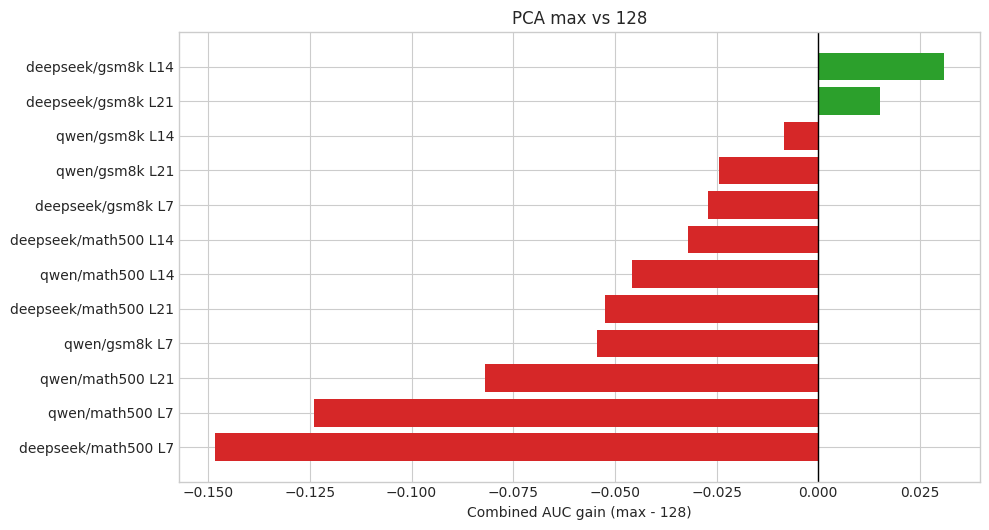


Mean gain: -0.0461
Share positive: 17%


In [5]:
def lookup_combined(model: str, dataset: str, layer: int, dim: str):
    match = next(
        (
            r
            for r in ablation_rows
            if r["model"] == model and r["dataset"] == dataset and int(r["layer"]) == layer and str(r["dim"]) == dim
        ),
        None,
    )
    return None if match is None else float(match["combined_auc"])


gain_rows = []
for model, dataset in conditions:
    layers_local = sorted({int(r["layer"]) for r in ablation_rows if r["model"] == model and r["dataset"] == dataset})
    for layer in layers_local:
        auc_128 = lookup_combined(model, dataset, layer, "128")
        auc_max = lookup_combined(model, dataset, layer, "max")
        if auc_128 is None or auc_max is None:
            continue
        gain_rows.append(
            {
                "label": f"{model}/{dataset} L{layer}",
                "model": model,
                "dataset": dataset,
                "layer": layer,
                "auc_128": auc_128,
                "auc_max": auc_max,
                "gain_max_minus_128": auc_max - auc_128,
            }
        )

gain_rows = sorted(gain_rows, key=lambda r: (r["gain_max_minus_128"], r["label"]))

gain_table = [
    [
        row["label"],
        f"{row['auc_128']:.3f}",
        f"{row['auc_max']:.3f}",
        f"{row['gain_max_minus_128']:+.4f}",
    ]
    for row in gain_rows
]
print("Gain from PCA max over PCA 128 (combined AUC)")
print(format_table(gain_table, ["condition/layer", "AUC@128", "AUC@max", "max-128"]))

if gain_rows:
    y = np.arange(len(gain_rows))
    values = np.array([row["gain_max_minus_128"] for row in gain_rows])
    labels = [row["label"] for row in gain_rows]
    colors = ["#2ca02c" if value >= 0 else "#d62728" for value in values]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(gain_rows))))
    ax.barh(y, values, color=colors)
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_yticks(y, labels)
    ax.set_xlabel("Combined AUC gain (max - 128)")
    ax.set_title("PCA max vs 128")
    fig.tight_layout()
    plt.show()

    mean_gain = float(np.mean(values))
    positive_share = float(np.mean(values > 0))
    print()
    print(f"Mean gain: {mean_gain:+.4f}")
    print(f"Share positive: {positive_share:.0%}")


## Conclusion

The interpretation prompts above resolve as follows:

- **`max - 128` gains are near zero or negative in 10 of 12 cells.** PCA
  truncation at 128 is not the bottleneck.
- **No consistent direction.** Best dim varies by cell (128 in 9 cells, 512 in
  1, `max` in 2) with no pattern by layer, model, or dataset — consistent with
  fold noise rather than a real dimension effect.
- **Retaining more components does not recover signal.** On both MATH-500
  conditions `max` is the worst setting, so the truncation is if anything mildly
  *helpful* as regularization.

Reported as a null. `pca_dim: 128` stays fixed in `params.yaml` and needs no
further defense.